In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt 
import seaborn as sns
import scipy.stats
from scipy.stats import chi2_contingency

In [3]:
df = pd.read_csv('players_22.csv', encoding='latin-1', low_memory=False)

   # What is the distribution of player ages in the dataset?

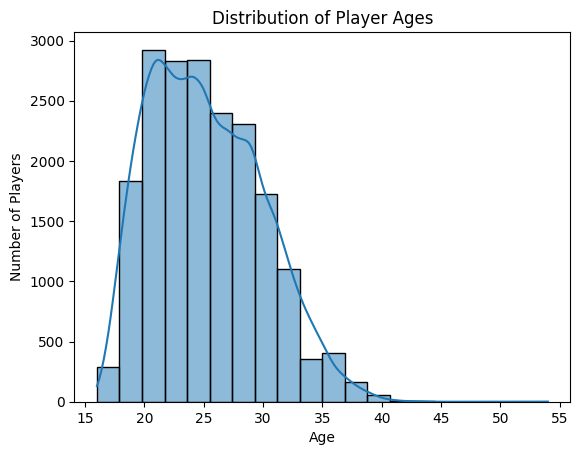

In [7]:
# Distribution of player ages
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Distribution of Player Ages')
plt.xlabel('Age')
plt.ylabel('Number of Players')
plt.show()

# How are player heights distributed across different positions?

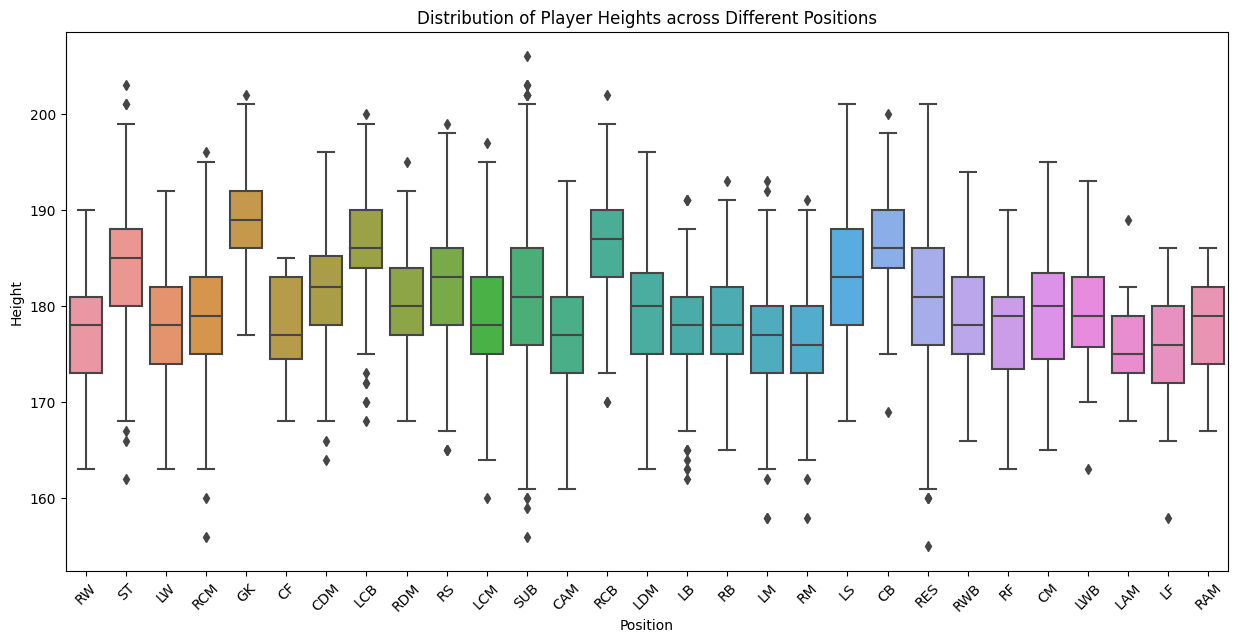

In [9]:
plt.figure(figsize=(15, 7))
sns.boxplot(data=df, x='club_position', y='height_cm')
plt.title('Distribution of Player Heights across Different Positions')
plt.xlabel('Position')
plt.ylabel('Height')
plt.xticks(rotation=45)
plt.show()

   # What is the average overall rating of players in the dataset?

In [11]:
average_rating = df['overall'].mean()
print(f"Average overall rating of players: {average_rating:.2f}")

Average overall rating of players: 65.77


# Which nationality is the most represented among the players?

In [14]:
most_common_nationality = df['nationality_name'].value_counts().idxmax()
print(f"The most represented nationality is: {most_common_nationality}")

The most represented nationality is: England


# What is the average wage of players in different age groups?

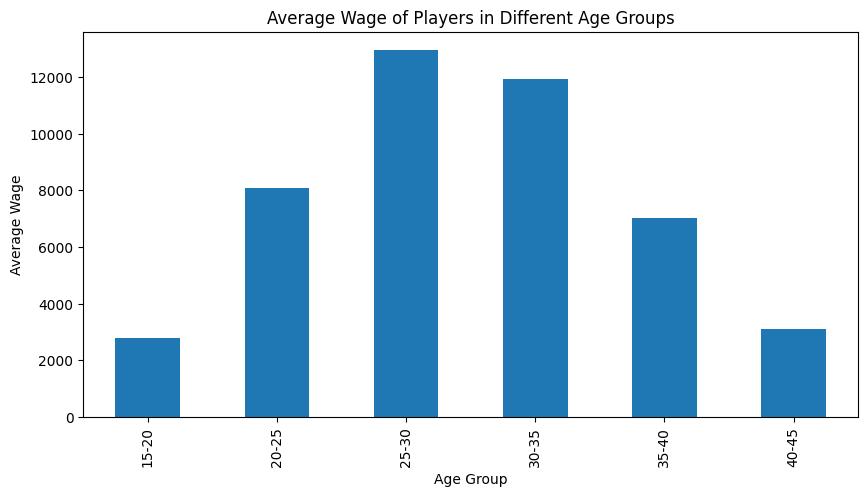

In [15]:
df['Age Group'] = pd.cut(df['age'], bins=[15, 20, 25, 30, 35, 40, 45], 
                         labels=['15-20', '20-25', '25-30', '30-35', '35-40', '40-45'])

average_wage_by_age = df.groupby('Age Group')['wage_eur'].mean()

plt.figure(figsize=(10, 5))
average_wage_by_age.plot(kind='bar')
plt.title('Average Wage of Players in Different Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Average Wage')
plt.show()


# Is there a correlation between a player's overall rating and their market value?

Correlation between overall rating and market value: 0.55


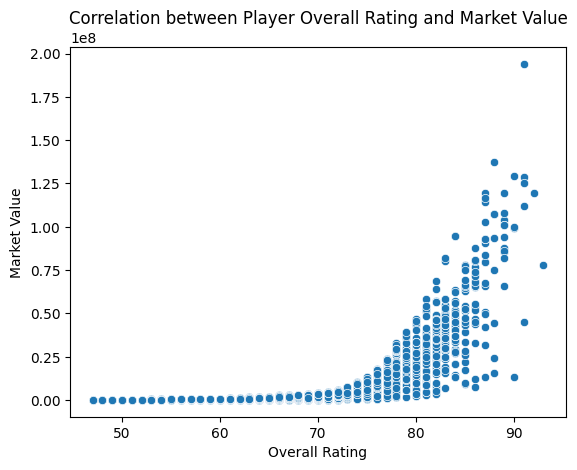

In [19]:
correlation = df['overall'].corr(df['value_eur'])
print(f"Correlation between overall rating and market value: {correlation:.2f}")

sns.scatterplot(data=df, x='overall', y='value_eur')
plt.title('Correlation between Player Overall Rating and Market Value')
plt.xlabel('Overall Rating')
plt.ylabel('Market Value')
plt.show()


# Who are the top 5 players with the highest overall ratings in the dataset?

In [21]:
top_5_players = df[['short_name', 'overall']].sort_values(by='overall', ascending=False).head(5)
print(top_5_players)

          short_name  overall
0           L. Messi       93
1     R. Lewandowski       92
2  Cristiano Ronaldo       91
3          Neymar Jr       91
4       K. De Bruyne       91


# How does the overall rating of Messi compare to Ronaldo in the dataset?

In [22]:
messi_rating = df[df['short_name'] == 'L. Messi']['overall'].values[0]
ronaldo_rating = df[df['short_name'] == 'Cristiano Ronaldo']['overall'].values[0]

print(f"Messi's overall rating: {messi_rating}")
print(f"Ronaldo's overall rating: {ronaldo_rating}")


Messi's overall rating: 93
Ronaldo's overall rating: 91


# What are the skill attributes that distinguish Cristiano Ronaldo from Lionel Messi in the dataset?

In [24]:
#skill_attributes = ['Dribbling', 'Passing', 'Shooting', 'Defending', 'Physical']


skill_attributes = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance', 'power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots', 'mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 'mentality_vision', 'mentality_penalties', 'mentality_composure', 'defending_marking_awareness', 'defending_standing_tackle', 'defending_sliding_tackle']

messi = df[df['short_name'] == 'L. Messi'][skill_attributes].values[0]
ronaldo = df[df['short_name'] == 'Cristiano Ronaldo'][skill_attributes].values[0]

diff = messi - ronaldo

for attribute, difference in zip(skill_attributes, diff):
    if difference > 0:
        print(f"Messi is better at {attribute} by {difference} points.")
    elif difference < 0:
        print(f"Ronaldo is better at {attribute} by {-difference} points.")
    else:
        print(f"Both have the same {attribute} skills.")


Ronaldo is better at pace by 2.0 points.
Ronaldo is better at shooting by 2.0 points.
Messi is better at passing by 11.0 points.
Messi is better at dribbling by 7.0 points.
Both have the same defending skills.
Ronaldo is better at physic by 10.0 points.
Ronaldo is better at attacking_crossing by 2.0 points.
Both have the same attacking_finishing skills.
Ronaldo is better at attacking_heading_accuracy by 20.0 points.
Messi is better at attacking_short_passing by 11.0 points.
Messi is better at attacking_volleys by 2.0 points.
Messi is better at skill_dribbling by 8.0 points.
Messi is better at skill_curve by 12.0 points.
Messi is better at skill_fk_accuracy by 10.0 points.
Messi is better at skill_long_passing by 14.0 points.
Messi is better at skill_ball_control by 8.0 points.
Messi is better at movement_acceleration by 6.0 points.
Ronaldo is better at movement_sprint_speed by 8.0 points.
Messi is better at movement_agility by 5.0 points.
Both have the same movement_reactions skills.
M

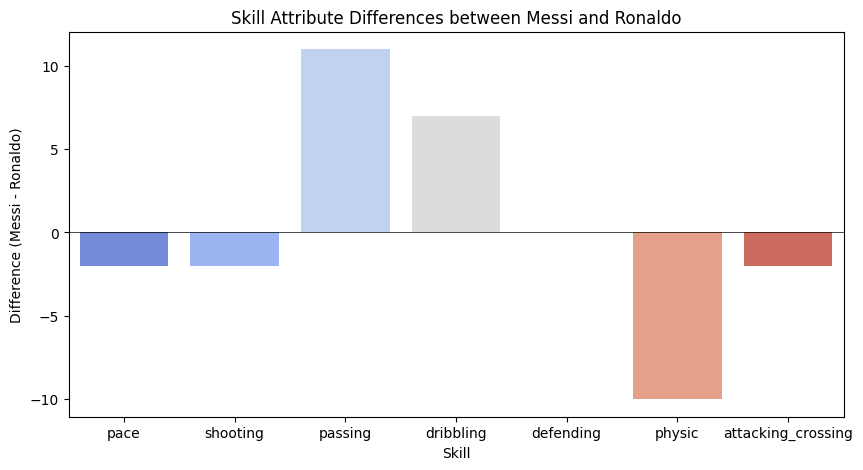

In [27]:

skill_attributes = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'attacking_crossing']


messi = df[df['short_name'] == 'L. Messi'][skill_attributes].values[0]
ronaldo = df[df['short_name'] == 'Cristiano Ronaldo'][skill_attributes].values[0]

diff = messi - ronaldo

# Create a DataFrame for visualization
diff_df = pd.DataFrame({
    'Skill': skill_attributes,
    'Difference': diff
})

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=diff_df, x='Skill', y='Difference', palette='coolwarm')
plt.title('Skill Attribute Differences between Messi and Ronaldo')
plt.ylabel('Difference (Messi - Ronaldo)')
plt.axhline(0, color='black',linewidth=0.5)
plt.show()


# Compare the preferred foot (left or right) of top goal scorers in the dataset.

           short_name  shooting preferred_foot
0            L. Messi      92.0           Left
1      R. Lewandowski      92.0          Right
2   Cristiano Ronaldo      94.0          Right
9             H. Kane      91.0          Right
23         L. SuÃ¡rez      90.0          Right
29         E. Haaland      91.0           Left


Text(0.5, 1.0, 'Preferred Foot of Players with Shooting >= 90')

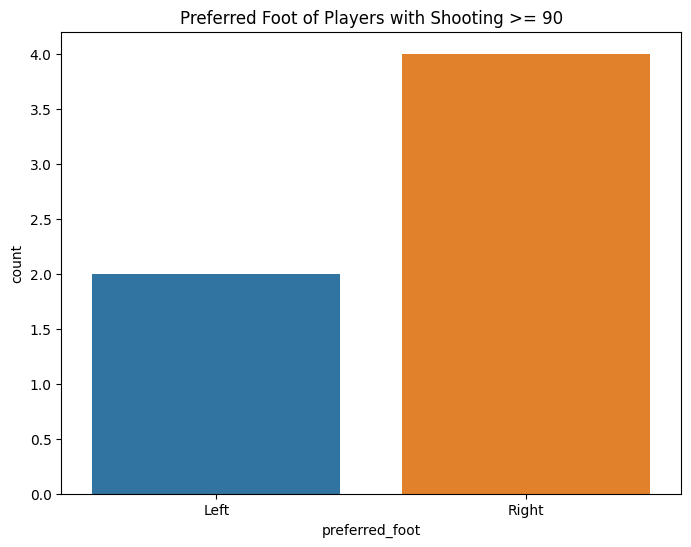

In [32]:
# Filter players with 'Shooting' >= 90
top_scorers = df[df['shooting'] >= 90][['short_name', 'shooting', 'preferred_foot']]

print(top_scorers)

# For visualization
plt.figure(figsize=(8, 6))
sns.countplot(data=top_scorers, x='preferred_foot')
plt.title('Preferred Foot of Players with Shooting >= 90')


# Compare the international reputation of players from different clubs or leagues.

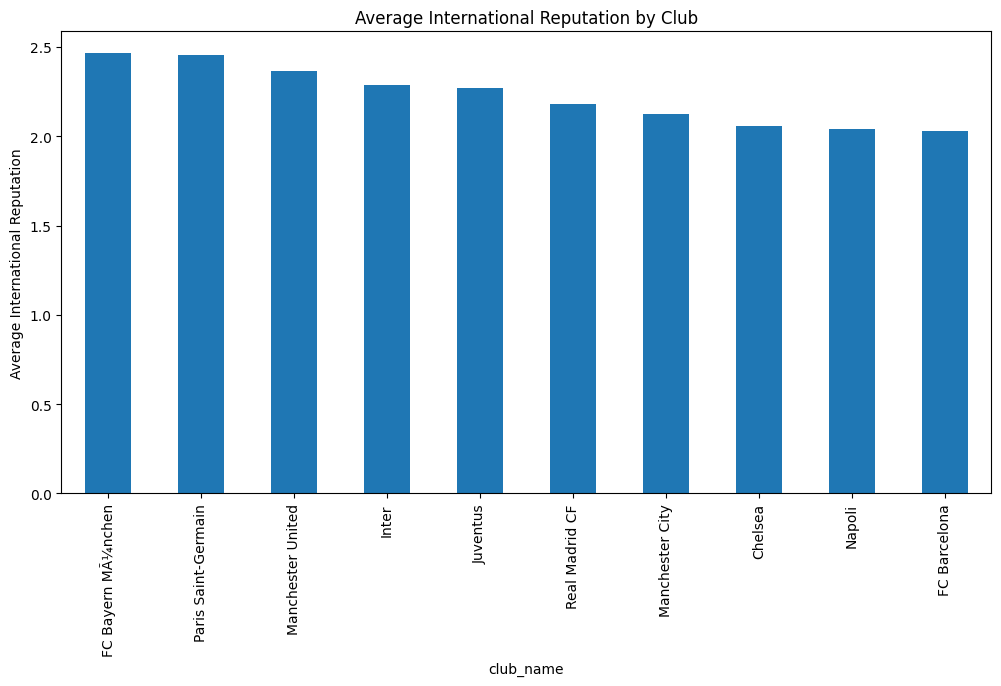

In [31]:
avg_rep_by_club = df.groupby('club_name')['international_reputation'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
avg_rep_by_club.head(10).plot(kind='bar')
plt.title('Average International Reputation by Club')
plt.ylabel('Average International Reputation')
plt.show()
